# RETINEXPLAIN
## Explainable Retinal Disease Detection via Concept Bottleneck Models and Fuzzy Pattern Trees

**Author:** Ashik Kannampilly Janardhanan | MSc Artificial Intelligence and Machine Learning  
**Student ID:** 25032615 | University of Limerick  
**Supervisors:** Dr. Allan de Lima and Dr. Douglas Mota Dias  
**Dissertation Deadline:** September 2026

---

### Pipeline Summary
This notebook implements a four-stage explainable pipeline for ocular disease classification from retinal fundus images:

1. **EfficientNet-B0** - Pre-trained backbone (frozen) extracts 1280 visual features per image
2. **Concept Bottleneck Layer (CBL)** - Trainable neural network maps 1280 features to 6 named clinical concept scores
3. **Adaptive Fuzzification** - Converts concept scores to fuzzy membership values using distribution-fitted triangular functions 
4. **Fuzzy Pattern Tree (FPT)** - Genetic Programming evolves a human-readable classifier over fuzzy features

### Dataset
ODIR-5K (Ocular Disease Intelligent Recognition) - retinal fundus images from 5000 patients, 7 disease classes.

---
## Section 1 -- Environment Setup

### Cell 1 -- Package Installation

#### Installs the required scikit-fuzzy and deap packages for fuzzy logic and genetic programming.

In [1]:
!pip install scikit-fuzzy deap -q
print("scikit-fuzzy and deap installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 18.3 MB/s eta 0:00:0000:01
scikit-fuzzy and deap installed successfully.


### Cell 2 -- Libraries

#### Imports all required libraries and fixes all random seeds for full reproducibility of the CBL training and GP evolution.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import math
import random
import itertools
import operator
import warnings
from scipy import stats
warnings.filterwarnings('ignore')
import statistics
from deap import tools, gp
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, precision_score, recall_score,
    roc_auc_score
)
from deap import creator, base, tools, gp
SEED = 123
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(SEED)
random.seed(SEED)

print("All libraries imported successfully.")

All libraries imported successfully.


### Cell 3 -- Setting up dataset File Paths

#### Sets the dataset, images and output directory paths and verifies that all required files and folders exist before any data loading begins.

In [3]:
DATASET_PATH = '/kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k'
IMAGES_PATH  = os.path.join(DATASET_PATH, 'preprocessed_images')
OUTPUT_PATH  = '/kaggle/working'

print("Path verification:")
print(f"  Dataset folder : {os.path.exists(DATASET_PATH)}")
print(f"  Images folder  : {os.path.exists(IMAGES_PATH)}")
print(f"  CSV file       : {os.path.exists(os.path.join(DATASET_PATH, 'full_df.csv'))}")

Path verification:
  Dataset folder : True
  Images folder  : True
  CSV file       : True


### Cell 4 -- FPT Utility Functions

#### Fuzzy operators used as building blocks inside the Fuzzy Pattern Tree. These include weighted averages, ordered weighted averages, and hedges such as dilator and concentrator that modify fuzzy membership values.

In [4]:
def replace_substrings(input_string, replacements):
    def replacer(match):
        index = int(match.group(1))
        return replacements[index]
    pattern = r'IN(\d+)'
    return re.sub(pattern, replacer, input_string)

def WA(a, b, x):
    x = float(x)
    return x*a+(1-x)*b

def OWA(a, b, x):
    x = float(x)
    return x*np.maximum(a, b)+(1-x)*np.minimum(a, b)

def minimum(a, b): return np.minimum(a, b)
def maximum(a, b): return np.maximum(a, b)
def dilator(b): return b**0.5
def concentrator(b): return b**2
def complement(b): return 1 - b

print("FPT utility functions ready.")

FPT utility functions ready.


### Cell 5 -- GP Algorithm

#### The Genetic Programming algorithm used to evolve Fuzzy Pattern Trees. At each generation, individuals are selected, crossed over and mutated. The best individual found across all generations is tracked in the hall of fame.

In [5]:
def varAnd(population, toolbox, cxpb, mutpb):
    offspring = [toolbox.clone(ind) for ind in population]
    for i in range(1, len(offspring), 2):
        if random.random() < cxpb:
            offspring[i-1], offspring[i] = toolbox.mate(offspring[i-1], offspring[i])
            del offspring[i-1].fitness.values, offspring[i].fitness.values
    for i in range(len(offspring)):
        if random.random() < mutpb:
            offspring[i], = toolbox.mutate(offspring[i])
            del offspring[i].fitness.values
    return offspring

def eaSimple(population, toolbox, cxpb, mutpb, ngen, points_train,
             points_test=None, report_items=None, stats=None, halloffame=None):
    logbook = tools.Logbook()
    logbook.header = report_items if report_items else ['gen', 'nevals', 'best_train_fitness']
    new_inds = [ind for ind in population if not ind.fitness.valid]
    n_evals = len(new_inds)
    for ind in new_inds:
        ind.fitness.values = toolbox.evaluate(ind, points_train)
    nodes = [getattr(ind, 'nodes') for ind in new_inds]
    avg_nodes = sum(nodes) / len(nodes)
    mce = [getattr(ind, 'mce') for ind in new_inds]
    avg_mce = sum(mce) / len(mce)
    behaviours = np.zeros([len(population), len(population[0].behaviour)], dtype=float)
    for idx, ind in enumerate(population):
        behaviours[idx, :] = ind.behaviour
    unique_behaviours = np.unique(behaviours, axis=0)
    behavioural_diversity = len(unique_behaviours) / len(population)
    if halloffame is not None:
        halloffame.update(population)
        best_train_fitness = halloffame.items[0].fitness.values[0]
        best_ind_mce = halloffame.items[0].mce
        best_ind_depth = halloffame.items[0].height
        best_ind_nodes = len(halloffame.items[0])
        print("gen =", 0, ", fitness =", best_train_fitness, ", MCE =", best_ind_mce, ", evals =", n_evals)
    logbook.record(gen=0, nevals=n_evals, best_train_fitness=best_train_fitness,
                   best_ind_mce=best_ind_mce, avg_mce=avg_mce,
                   best_ind_depth=best_ind_depth, best_ind_nodes=best_ind_nodes,
                   avg_nodes=avg_nodes, fitness_test=np.nan,
                   behavioural_diversity=behavioural_diversity,
                   lexicase_avg_steps=0, lexicase_avg_ties_chosen_ind=0,
                   avg_zeros=0, avg_epsilon=0, variance=0, unique_selected=0,
                   behavioural_diversity_fitness_cases=0,
                   accuracy_test=np.nan, best_phenotype=np.nan)
    for gen in range(1, ngen + 1):
        offspring = toolbox.select(population, len(population))
        offspring = varAnd(offspring, toolbox, cxpb, mutpb)
        new_inds = [ind for ind in offspring if not ind.fitness.valid]
        n_evals = len(new_inds)
        for ind in new_inds:
            ind.fitness.values = toolbox.evaluate(ind, points_train)
        nodes = [getattr(ind, 'nodes') for ind in offspring]
        avg_nodes = sum(nodes) / len(nodes)
        mce = [getattr(ind, 'mce') for ind in new_inds]
        avg_mce = sum(mce) / len(mce)
        population[:] = offspring
        behaviours = np.zeros([len(population), len(population[0].behaviour)], dtype=float)
        for idx, ind in enumerate(population):
            behaviours[idx, :] = ind.behaviour
        unique_behaviours = np.unique(behaviours, axis=0)
        behavioural_diversity = len(unique_behaviours) / len(population)
        if halloffame is not None:
            halloffame.update(population)
            best_train_fitness = halloffame.items[0].fitness.values[0]
            best_ind_mce = halloffame.items[0].mce
            best_ind_depth = halloffame.items[0].height
            best_ind_nodes = len(halloffame.items[0])
            print("gen =", gen, ", fitness =", best_train_fitness, ", MCE =", best_ind_mce, ", evals =", n_evals)
        fitness_test = np.nan
        if points_test and gen == ngen:
            toolbox.evaluate(halloffame.items[0], points_test)
            fitness_test = halloffame.items[0].mce
        logbook.record(gen=gen, nevals=n_evals, best_train_fitness=best_train_fitness,
                       best_ind_mce=best_ind_mce, avg_mce=avg_mce,
                       best_ind_depth=best_ind_depth, best_ind_nodes=best_ind_nodes,
                       avg_nodes=avg_nodes, fitness_test=fitness_test,
                       behavioural_diversity=behavioural_diversity,
                       lexicase_avg_steps=0, lexicase_avg_ties_chosen_ind=0,
                       avg_zeros=0, avg_epsilon=0, variance=0, unique_selected=0,
                       behavioural_diversity_fitness_cases=0,
                       accuracy_test=np.nan, best_phenotype=np.nan)
    return population, logbook

print("GP algorithm ready.")

GP algorithm ready.


---
## Section 2 -- Dataset Preparation

### Cell 6 -- Loading Dataset

#### Loads the ODIR-5K CSV file and displays the first three rows to verify the structure of the raw dataset before any cleaning or filtering is applied.

In [6]:
df = pd.read_csv(os.path.join(DATASET_PATH, 'full_df.csv'))
print(f"Loaded {len(df)} rows from full_df.csv")
df.head(3)

Loaded 6392 rows from full_df.csv


,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O,filepath,labels,target,filename
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",0_right.jpg
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",1_right.jpg
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",2_right.jpg


### Cell 7 -- Dataset Cleaning

#### Parses the labels column to extract single disease codes, removes multi-label and Other category rows, and prints the final class distribution across the seven disease classes. 

In [7]:
label_map = {
    'N': 'Normal',
    'D': 'Diabetic Retinopathy',
    'G': 'Glaucoma',
    'C': 'Cataract',
    'A': 'AMD',
    'H': 'Hypertension',
    'M': 'Myopia'
}

# The labels column contains values like "['N']" so we are extracting the single letter from the string
def parse_label(label_str):
    cleaned = str(label_str).replace('[', '').replace(']', '').replace("'", '').strip()
    return cleaned

df['label_parsed'] = df['labels'].apply(parse_label)

# Keeping only single-disease patients (excluding: Other 'O' and any multi-label)
df_clean = df[df['label_parsed'].isin(label_map.keys())].copy()
df_clean['label'] = df_clean['label_parsed']
df_clean['disease_name'] = df_clean['label'].map(label_map)

print(f"Total images after cleaning: {len(df_clean)}")
print()
print("Class distribution:")
for disease, count in df_clean['disease_name'].value_counts().items():
    pct = count / len(df_clean) * 100
    print(f"  {disease:<30}: {count:5d} ({pct:.1f}%)")

Total images after cleaning: 5684

Class distribution:
  Normal                        :  2873 (50.5%)
  Diabetic Retinopathy          :  1608 (28.3%)
  Cataract                      :   293 (5.2%)
  Glaucoma                      :   284 (5.0%)
  AMD                           :   266 (4.7%)
  Myopia                        :   232 (4.1%)
  Hypertension                  :   128 (2.3%)


### Cell 8 -- Class Distribution Plot

 #### Bar chart and pie chart showing the class distribution of the ODIR-5K dataset after cleaning. The severe imbalance between Normal/DR and minority classes is the primary challenge for the classification system.

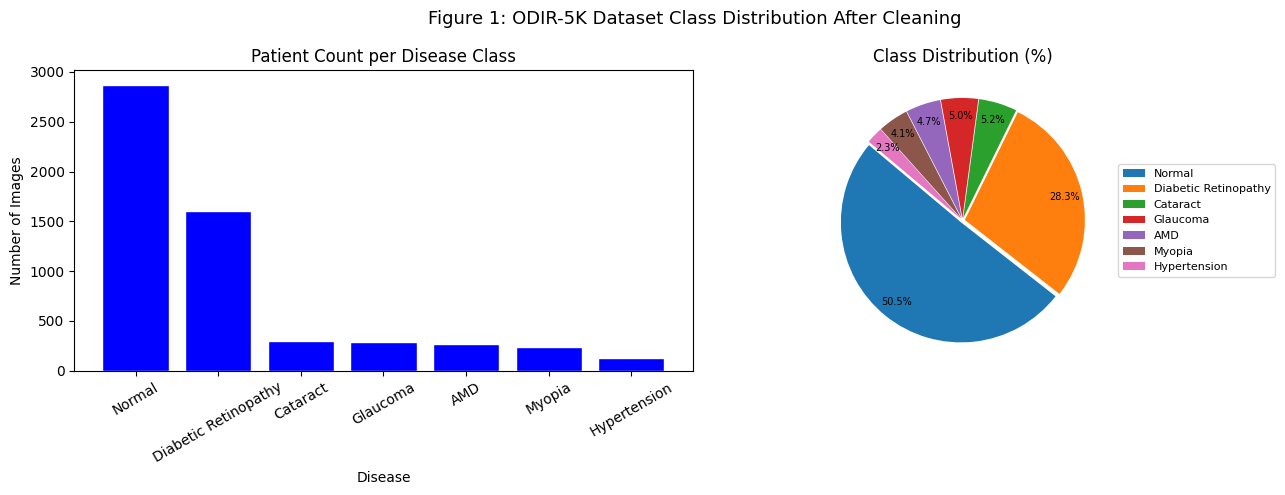

Figure 1 saved.


In [8]:
counts = df_clean['disease_name'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(counts.index, counts.values, color='blue', edgecolor='white')
axes[0].set_title('Patient Count per Disease Class')
axes[0].set_xlabel('Disease')
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=30)

axes[1].pie(counts.values, autopct='%1.1f%%', startangle=140, pctdistance=0.85, explode=[0.02] * len(counts), textprops={'fontsize': 7})
axes[1].legend(counts.index,loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), fontsize=8)
axes[1].set_title('Class Distribution (%)')

plt.suptitle('Figure 1: ODIR-5K Dataset Class Distribution After Cleaning', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'fig1_class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")

### Cell 9 -- Patient-Level Train/Validation/Test Split

#### The split is performed at **patient level** with stratification. Both left and right eye images of the same patient always appear in the same split, preventing data leakage between splits.

#### Split ratios: 70% training, 15% validation, 15% test.

In [9]:
patient_labels = df_clean.groupby('ID')['label'].first().reset_index()

train_ids, temp_ids = train_test_split(patient_labels['ID'], test_size=0.30, random_state=42, stratify=patient_labels['label'])
temp_labels = patient_labels[patient_labels['ID'].isin(temp_ids)]
val_ids, test_ids = train_test_split(temp_labels['ID'], test_size=0.50, random_state=42, stratify=temp_labels['label'])

df_train = df_clean[df_clean['ID'].isin(train_ids)].copy().reset_index(drop=True)
df_val   = df_clean[df_clean['ID'].isin(val_ids)].copy().reset_index(drop=True)
df_test  = df_clean[df_clean['ID'].isin(test_ids)].copy().reset_index(drop=True)

print("Split results (patient-level, stratified):")
print(f"  Training:   {len(df_train):5d} images ({len(df_train)/len(df_clean)*100:.1f}%)")
print(f"  Validation: {len(df_val):5d} images ({len(df_val)/len(df_clean)*100:.1f}%)")
print(f"  Test:       {len(df_test):5d} images ({len(df_test)/len(df_clean)*100:.1f}%)")
print()
print("Patient overlap check :")
print(f"  Train/Val:  {len(set(train_ids) & set(val_ids))}")
print(f"  Train/Test: {len(set(train_ids) & set(test_ids))}")
print(f"  Val/Test:   {len(set(val_ids) & set(test_ids))}")

Split results (patient-level, stratified):
  Training:    3973 images (69.9%)
  Validation:   851 images (15.0%)
  Test:         860 images (15.1%)

Patient overlap check :
  Train/Val:  0
  Train/Test: 0
  Val/Test:   0


### Cell 10 -- Concept Label Extraction

#### Six clinical concepts are extracted from the ODIR-5K diagnostic keyword text fields using keyword matching. Each concept represents a visual biomarker observable in retinal fundus images.

#### The concepts disc_pallor, drusen, and vessel_tortuosity are derived from keywords that directly imply specific diseases (Glaucoma, AMD, and Hypertension, respectively) in 100% of cases. These function as proxies for disease labels rather than fully independent visual signs. So for theses the concepts are derived from diagnostic keywords.

In [10]:
CONCEPT_KEYWORDS = {
    'haemorrhage': [
        'intraretinal hemorrhage', 'severe nonproliferative retinopathy',
        'proliferative diabetic retinopathy', 'hypertensive retinopathy',
        'branch retinal vein occlusion', 'central retinal vein occlusion'
    ],
    'drusen': [
        'drusen', 'dry age-related macular degeneration'
    ],
    'disc_pallor': [
        'optic nerve atrophy', 'glaucoma', 'suspected glaucoma'
    ],
    'vessel_tortuosity': [
        'vessel tortuosity', 'hypertensive retinopathy', 'white vessel'
    ],
    'red_spot': [
        'mild nonproliferative retinopathy', 'diabetic retinopathy',
        'intraretinal microvascular abnormality'
    ],
    'exudate': [
        'maculopathy', 'wet age-related macular degeneration',
        'moderate non proliferative retinopathy'
    ]
}

concepts_list    = list(CONCEPT_KEYWORDS.keys())
concepts_display = ['Haemorrhage', 'Drusen', 'Disc Pallor', 'Vessel Tortuosity', 'Red Spot', 'Exudate']

def extract_concepts(text):
    if pd.isna(text):
        text = ''
    text = text.lower()
    result = {}
    for concept, keywords in CONCEPT_KEYWORDS.items():
        result[concept] = 1 if any(kw in text for kw in keywords) else 0
    return result
# Deriving eye from filename
df_clean['eye_keywords'] = df_clean.apply(
    lambda row: row['Left-Diagnostic Keywords'] if 'left' in str(row['filename']).lower()
                else row['Right-Diagnostic Keywords'],
    axis=1
)

concepts_df = pd.DataFrame( list(df_clean['eye_keywords'].apply(extract_concepts)), index=df_clean.index )
for c in concepts_list:
    df_clean[c] = concepts_df[c]
concept_map = df_clean.set_index('filename')[concepts_list]
for c in concepts_list:
    df_train[c] = df_train['filename'].map(concept_map[c]).fillna(0).astype(int).values
    df_val[c]   = df_val['filename'].map(concept_map[c]).fillna(0).astype(int).values
    df_test[c]  = df_test['filename'].map(concept_map[c]).fillna(0).astype(int).values

print("Concept label extraction complete (per-image, per-eye).")
print()
print("Coverage in training set:")
for concept, display in zip(concepts_list, concepts_display):
    count = int(df_train[concept].sum())
    pct   = count / len(df_train) * 100
    print(f"  {display:<22}: {count:4d} samples ({pct:.1f}%)")

Concept label extraction complete (per-image, per-eye).

Coverage in training set:
  Haemorrhage           :  254 samples (6.4%)
  Drusen                :  168 samples (4.2%)
  Disc Pallor           :  222 samples (5.6%)
  Vessel Tortuosity     :  138 samples (3.5%)
  Red Spot              :  410 samples (10.3%)
  Exudate               :  696 samples (17.5%)


### Cell 11 -- Concept Coverage and Correlation

#### The red dashed line indicates the 5% minimum threshold for meaningful supervision. Vessel Tortuosity falls below this threshold, indicating sparse positive examples.

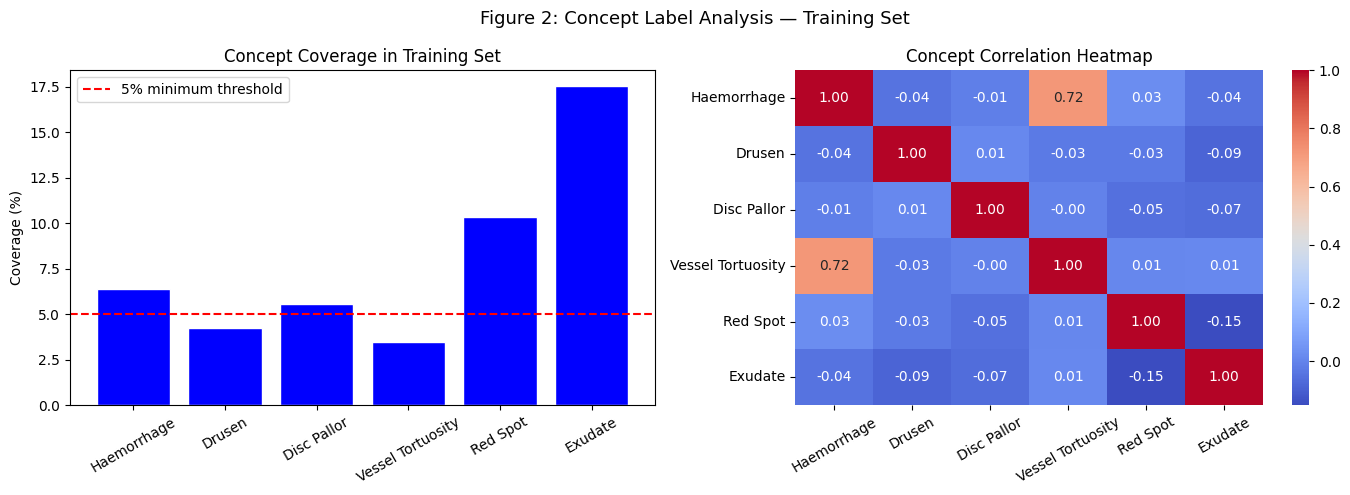

Figure 2 saved.


In [11]:
coverage_values = [df_train[c].sum() / len(df_train) * 100 for c in concepts_list]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(concepts_display, coverage_values, color='blue', edgecolor='white')
axes[0].axhline(y=5, color='red', linestyle='--', label='5% minimum threshold')
axes[0].set_title('Concept Coverage in Training Set')
axes[0].set_ylabel('Coverage (%)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()

corr = df_train[concepts_list].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', xticklabels=concepts_display, yticklabels=concepts_display, ax=axes[1])
axes[1].set_title('Concept Correlation Heatmap')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Figure 2: Concept Label Analysis — Training Set', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'fig2_concept_coverage.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")

---
## Section 3 -- EfficientNet-B0 + Concept Bottleneck Layer

### Cell 12 -- Retinal Image Dataset

#### Retinal fundus images are loaded and preprocessed for training. Random augmentations are applied to training images to improve generalisation. Validation and test images are left unchanged for fair evaluation.

In [12]:
class RetinalDataset(Dataset):
    def __init__(self, dataframe, images_path, concepts_list, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.images_path = images_path
        self.concepts_list = concepts_list
        self.transform = transform
        self.samples = []

        for _, row in self.df.iterrows():
            img_path = os.path.join(self.images_path, row['filename'])
            if os.path.exists(img_path):
                concept_labels = [float(row[c]) for c in self.concepts_list]
                self.samples.append((img_path, concept_labels))

        print(f"  Dataset ready: {len(self.samples)} valid images")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, concept_labels = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(concept_labels, dtype=torch.float32)


train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Creating image datasets...")
train_dataset = RetinalDataset(df_train, IMAGES_PATH, concepts_list, train_transform)
val_dataset   = RetinalDataset(df_val,   IMAGES_PATH, concepts_list, val_transform)
test_dataset  = RetinalDataset(df_test,  IMAGES_PATH, concepts_list, val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Creating image datasets...
  Dataset ready: 3973 valid images
  Dataset ready: 851 valid images
  Dataset ready: 860 valid images
Train batches: 125 | Val batches: 27


### Cell 13 -- Build Concept Bottleneck Model

#### A pre-trained EfficientNet-B0 acts as a fixed visual feature extractor, producing 1280 features per image. A small trainable Concept Bottleneck Layer then maps these features to 6 clinical concept scores.

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

class ConceptBottleneckModel(nn.Module):
    def __init__(self, num_concepts=6):
        super().__init__()
        backbone = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(backbone.children())[:-1])
        # Freezing the backbone — use ImageNet features as fixed visual descriptors
        for param in self.backbone.parameters():
            param.requires_grad = False
        # Trainable concept bottleneck: 1280 visual features → 6 concept scores
        self.concept_layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1280, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 6)
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.concept_layer(features)

model = ConceptBottleneckModel(num_concepts=6).to(device)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total  = sum(p.numel() for p in model.parameters())
print(f"EfficientNet-B0 backbone (frozen):   {total - trainable:,} parameters")
print(f"Concept Bottleneck Layer (trainable): {trainable:,} parameters")

Device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 171MB/s]


EfficientNet-B0 backbone (frozen):   4,007,548 parameters
Concept Bottleneck Layer (trainable): 329,478 parameters


### Cell 14 -- Train Concept Bottleneck Layer

#### The Concept Bottleneck Layer is trained to predict the six concept labels from the visual features. Positive class weights are applied to compensate for the rarity of most concepts in the dataset. Early stopping prevents overfitting.

**Training configuration:**
- Loss: BCEWithLogitsLoss with positive class weights capped at 10 to handle concept label imbalance
- Optimiser: Adam with lr=0.0001 and weight_decay=1e-4 to reduce overfitting
- Early stopping with patience=7


In [14]:
# Computing positive class weights to handle concept label imbalance
# Weight = (number of negatives) / (number of positives), capped at 10
raw_weights = torch.tensor([
    (len(df_train) - df_train['haemorrhage'].sum())      / max(df_train['haemorrhage'].sum(), 1),
    (len(df_train) - df_train['drusen'].sum())           / max(df_train['drusen'].sum(), 1),
    (len(df_train) - df_train['disc_pallor'].sum())      / max(df_train['disc_pallor'].sum(), 1),
    (len(df_train) - df_train['vessel_tortuosity'].sum())/ max(df_train['vessel_tortuosity'].sum(), 1),
    (len(df_train) - df_train['red_spot'].sum())         / max(df_train['red_spot'].sum(), 1),
    (len(df_train) - df_train['exudate'].sum())          / max(df_train['exudate'].sum(), 1),
])
pos_weight = torch.clamp(raw_weights, max=10.0).to(device)

print("Positive class weights per concept (capped at 10):")
for c, w in zip(concepts_list, pos_weight.cpu()):
    print(f"  {c:<25}: {w:.2f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

EPOCHS   = 50
PATIENCE = 7
best_val_loss = float('inf')
patience_counter = 0
train_losses  = []
val_losses  = []
best_model_state = None

print(f"\nTraining CBL for up to {EPOCHS} epochs...")
print()

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            val_loss += criterion(model(images), labels).item()
    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)
    print(f"Epoch {epoch+1:3d}/{EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f}", end='')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
        print(" <-- Best")
    else:
        patience_counter += 1
        print()
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch + 1}")
            break

model.load_state_dict(best_model_state)
print(f"\nTraining complete. Best validation loss: {best_val_loss:.4f}")

Positive class weights per concept (capped at 10):
  haemorrhage              : 10.00
  drusen                   : 10.00
  disc_pallor              : 10.00
  vessel_tortuosity        : 10.00
  red_spot                 : 8.69
  exudate                  : 4.71

Training CBL for up to 50 epochs...

Epoch   1/50 | Train: 1.0159 | Val: 0.9699 <-- Best
Epoch   2/50 | Train: 0.9661 | Val: 0.9314 <-- Best
Epoch   3/50 | Train: 0.9301 | Val: 0.9022 <-- Best
Epoch   4/50 | Train: 0.9053 | Val: 0.8806 <-- Best
Epoch   5/50 | Train: 0.8895 | Val: 0.8642 <-- Best
Epoch   6/50 | Train: 0.8651 | Val: 0.8528 <-- Best
Epoch   7/50 | Train: 0.8567 | Val: 0.8441 <-- Best
Epoch   8/50 | Train: 0.8394 | Val: 0.8411 <-- Best
Epoch   9/50 | Train: 0.8471 | Val: 0.8357 <-- Best
Epoch  10/50 | Train: 0.8264 | Val: 0.8292 <-- Best
Epoch  11/50 | Train: 0.8214 | Val: 0.8270 <-- Best
Epoch  12/50 | Train: 0.8140 | Val: 0.8181 <-- Best
Epoch  13/50 | Train: 0.8119 | Val: 0.8179 <-- Best
Epoch  14/50 | Train: 0.801

### Cell 15 -- CBL Training Curves
#### Training and validation loss curves for the Concept Bottleneck Layer.

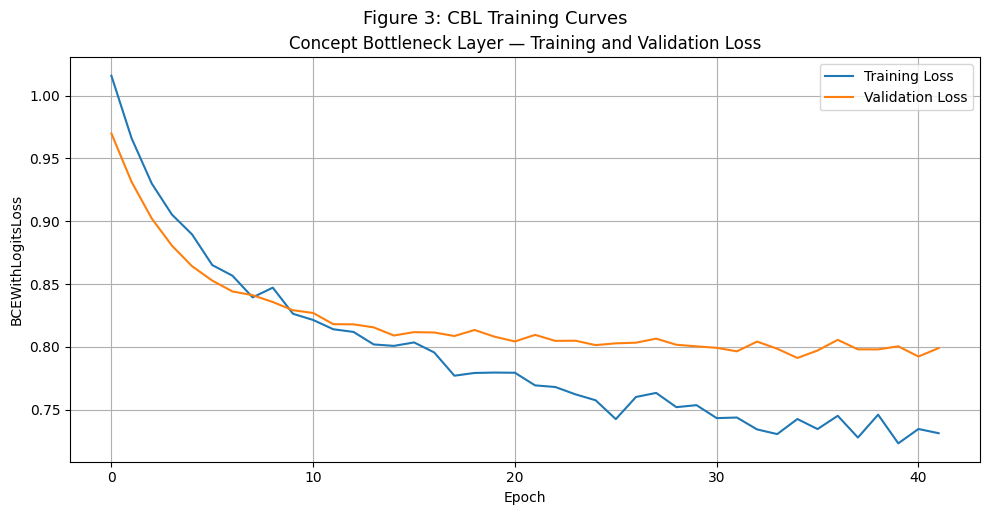

Figure 3 saved.


In [15]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses,   label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('BCEWithLogitsLoss')
plt.title('Concept Bottleneck Layer — Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.suptitle('Figure 3: CBL Training Curves', fontsize=13, y=1.02)
plt.savefig(os.path.join(OUTPUT_PATH, 'fig3_cbl_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved.")

### Cell 16 -- Extract Concept Scores

#### The trained CBL is used to extract a six-dimensional concept score vector for every image in the training, validation and test sets.

In [16]:
def get_concept_scores(loader, model, device):
    model.eval()
    all_scores = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            scores = torch.sigmoid(model(images))
            all_scores.append(scores.cpu().numpy())
            all_labels.append(labels.numpy())
    return np.concatenate(all_scores), np.concatenate(all_labels)

# Separating non-shuffled loader for score extraction, as this ensures scores come out in the same order as the training labels
train_eval_loader = DataLoader(train_dataset, batch_size=32, shuffle=False, num_workers=2)

print("Extracting concept scores...")
train_scores, train_concept_labels = get_concept_scores(train_eval_loader, model, device)
val_scores,   val_concept_labels   = get_concept_scores(val_loader,        model, device)
test_scores,  test_concept_labels  = get_concept_scores(test_loader,       model, device)

print(f"Train: {train_scores.shape} | Val: {val_scores.shape} | Test: {test_scores.shape}")
print()
print("Mean concept score per concept (training set):")
for i, display_name in enumerate(concepts_display):
    mean = train_scores[:, i].mean()
    print(f"  {display_name:<22}: {mean:.4f}")

Extracting concept scores...
Train: (3973, 6) | Val: (851, 6) | Test: (860, 6)

Mean concept score per concept (training set):
  Haemorrhage           : 0.2926
  Drusen                : 0.2279
  Disc Pallor           : 0.2329
  Vessel Tortuosity     : 0.2080
  Red Spot              : 0.4580
  Exudate               : 0.4327


### Cell 17 -- Per-Concept CBL Evaluation

#### AUC, precision and recall are computed per concept on the validation set to assess how well the CBL has learned to detect each clinical sign from the retinal images.

In [17]:
print("Per-concept CBL evaluation on Validation Set:")
print()
print(f"{'Concept':<22}  {'AUC':>6}  {'Precision':>9}  {'Recall':>6}  {'Pos samples':>11}")
print("-" * 60)

for i, (c, d) in enumerate(zip(concepts_list, concepts_display)):
    true_labels  = val_concept_labels[:, i]
    pred_scores  = val_scores[:, i]
    pred_binary  = (pred_scores > 0.5).astype(int)
    pos_count    = int(true_labels.sum())

    try:
        auc = roc_auc_score(true_labels, pred_scores)
    except ValueError:
        auc = float('nan')  

    prec = precision_score(true_labels, pred_binary, zero_division=0)
    rec  = recall_score(true_labels, pred_binary, zero_division=0)

    print(f"{d:<22}  {auc:>6.3f}  {prec:>9.3f}  {rec:>6.3f}  {pos_count:>11d}")


Per-concept CBL evaluation on Validation Set:

Concept                    AUC  Precision  Recall  Pos samples
------------------------------------------------------------
Haemorrhage              0.867      0.290   0.750           60
Drusen                   0.727      0.182   0.286           35
Disc Pallor              0.887      0.240   0.705           44
Vessel Tortuosity        0.848      0.229   0.407           27
Red Spot                 0.687      0.145   0.744           86
Exudate                  0.678      0.230   0.622          127


### Cell 18 -- Concept Score Distributions

#### Distribution of concept scores across the training set. P10, P50 and P90 mark the 10th, 50th and 90th percentiles respectively, showing how scores are spread across patients and revealing whether the CBL is producing meaningful variation or concentrating scores near zero.

Concept score percentiles (training set):
Concept                    P10     P50     P90
---------------------------------------------
Haemorrhage              0.042   0.227   0.664
Drusen                   0.041   0.177   0.489
Disc Pallor              0.017   0.146   0.594
Vessel Tortuosity        0.023   0.148   0.497
Red Spot                 0.180   0.486   0.676
Exudate                  0.164   0.431   0.702


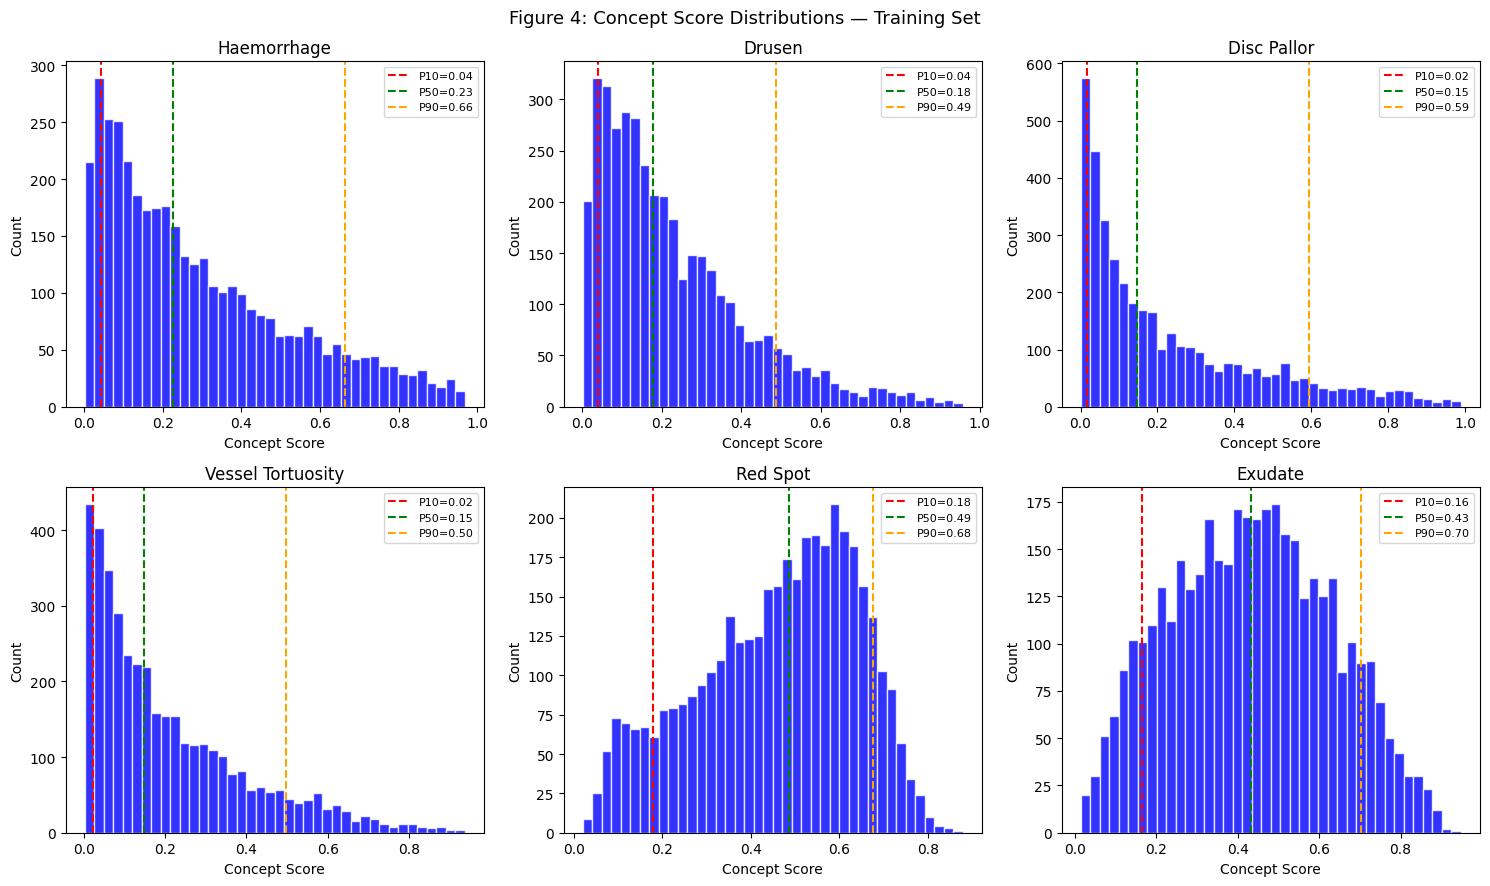

Figure 4 saved.


In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

print("Concept score percentiles (training set):")
print(f"{'Concept':<22}  {'P10':>6}  {'P50':>6}  {'P90':>6}")
print("-" * 45)

for i, (c, d) in enumerate(zip(concepts_list, concepts_display)):
    p10 = np.percentile(train_scores[:, i], 10)
    p50 = np.percentile(train_scores[:, i], 50)
    p90 = np.percentile(train_scores[:, i], 90)
    print(f"{d:<22}  {p10:>6.3f}  {p50:>6.3f}  {p90:>6.3f}")

    axes[i].hist(train_scores[:, i], bins=40, color='blue', edgecolor='white', alpha=0.8)
    axes[i].axvline(x=p10, color='red',    linestyle='--', label=f'P10={p10:.2f}')
    axes[i].axvline(x=p50, color='green',  linestyle='--', label=f'P50={p50:.2f}')
    axes[i].axvline(x=p90, color='orange', linestyle='--', label=f'P90={p90:.2f}')
    axes[i].set_title(d)
    axes[i].set_xlabel('Concept Score')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

plt.suptitle('Figure 4: Concept Score Distributions — Training Set', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'fig4_concept_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 saved.")

---
## Section 4 -- Adaptive Fuzzification

### Cell 19 -- Build Feature DataFrames

#### Patient age and sex are extracted from the dataset and combined with the six concept scores to form the complete feature matrix used for fuzzification. Each row represents one retinal image described by eight values - six concept scores, age and sex. These demographic features are included because certain diseases are strongly associated with patient age and sex, providing additional discriminative signal beyond the visual concepts alone.

In [19]:
def build_metadata(df_split, n_samples):
    ages, sexes, labels = [], [], []
    for _, row in df_split.iterrows():
        img_path = os.path.join(IMAGES_PATH, row['filename'])
        if os.path.exists(img_path):
            ages.append(float(row['Patient Age']))
            sexes.append(1.0 if str(row['Patient Sex']).lower() == 'male' else 0.0)
            labels.append(row['label'])
    return ages[:n_samples], sexes[:n_samples], labels[:n_samples]

train_ages, train_sexes, train_labels = build_metadata(df_train, len(train_scores))
val_ages,   val_sexes,   val_labels   = build_metadata(df_val,   len(val_scores))
test_ages,  test_sexes,  test_labels  = build_metadata(df_test,  len(test_scores))

def make_feature_df(scores, ages, sexes):
    df = pd.DataFrame(scores, columns=concepts_list)
    df['age'] = ages
    df['sex'] = sexes
    return df

df_train_feat = make_feature_df(train_scores, train_ages, train_sexes)
df_val_feat   = make_feature_df(val_scores,   val_ages,   val_sexes)
df_test_feat  = make_feature_df(test_scores,  test_ages,  test_sexes)

print(f"Feature matrix shape: {df_train_feat.shape}")
print(f"Columns: {list(df_train_feat.columns)}")
df_train_feat.head(3)

Feature matrix shape: (3973, 8)
Columns: ['haemorrhage', 'drusen', 'disc_pallor', 'vessel_tortuosity', 'red_spot', 'exudate', 'age', 'sex']


,haemorrhage,drusen,disc_pallor,vessel_tortuosity,red_spot,exudate,age,sex
0,0.028561,0.033302,0.368248,0.013402,0.293700,0.180694,69.0,0.0
1,0.550524,0.231296,0.389660,0.295825,0.398621,0.788030,42.0,1.0
2,0.413502,0.294448,0.591837,0.476830,0.333756,0.530689,53.0,1.0


### Cell 20 -- Class-Conditional Score Histograms

#### Concept score distributions across disease classes on the test set, showing how well the CBL separates each clinical sign by disease.

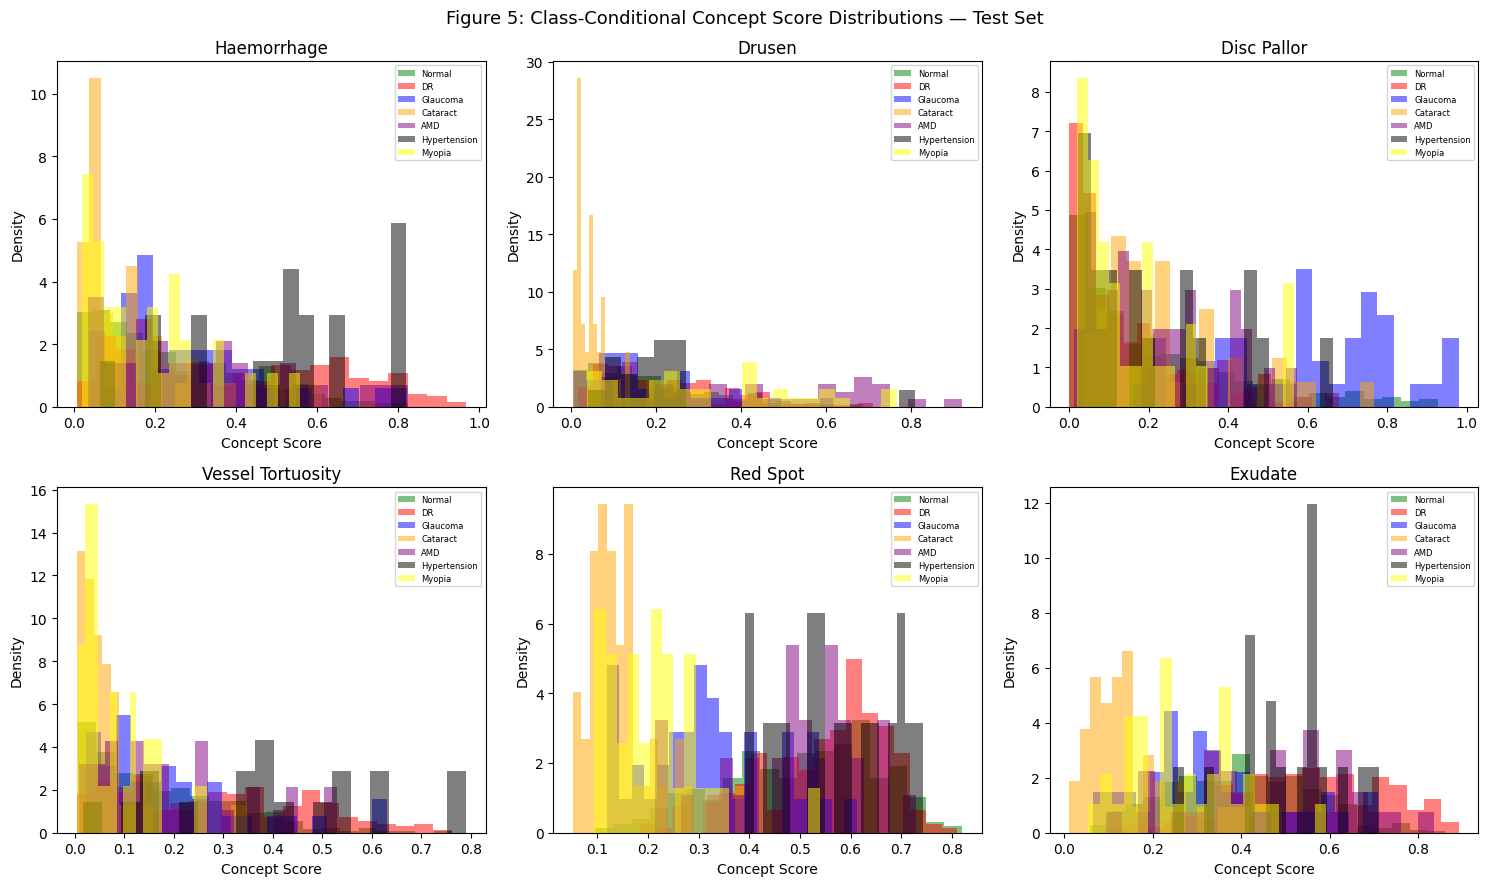

In [20]:
label_to_idx_map = {'N': 0, 'D': 1, 'G': 2, 'C': 3, 'A': 4, 'H': 5, 'M': 6}
idx_to_name_map  = {0: 'Normal', 1: 'DR', 2: 'Glaucoma', 3: 'Cataract',
                    4: 'AMD', 5: 'Hypertension', 6: 'Myopia'}
class_colors = ['green', 'red', 'blue', 'orange', 'purple', 'black', 'yellow']

test_label_array = np.array([label_to_idx_map[l] for l in test_labels])

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (c, d) in enumerate(zip(concepts_list, concepts_display)):
    ax = axes[i]
    for class_idx in range(7):
        mask = test_label_array == class_idx
        if mask.sum() > 0:
            scores_for_class = test_scores[mask, i]
            ax.hist(scores_for_class, bins=20, alpha=0.5, label=idx_to_name_map[class_idx], color=class_colors[class_idx], density=True)
    ax.set_title(d)
    ax.set_xlabel('Concept Score')
    ax.set_ylabel('Density')
    ax.legend(fontsize=6, loc='upper right')

plt.suptitle('Figure 5: Class-Conditional Concept Score Distributions — Test Set', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'fig5_class_conditional_scores.png'), dpi=150, bbox_inches='tight')
plt.show()

### Cell 21 -- Adaptive Fuzzification 

#### Each concept score and patient age is converted into three fuzzy membership values, LOW, MEDIUM and HIGH, using triangular membership functions. The triangle bounds are adapted to the actual data distribution of each feature rather than assuming a uniform spread, ensuring the fuzzy sets capture meaningful variation in the data.

In [21]:
numerical_cols   = concepts_list + ['age']
categorical_cols = ['sex']

def fit_best_distribution(data):
    data  = np.array(data)
    d_min = data.min()
    d_max = data.max()
    d_range = d_max - d_min
    if d_range == 0:
        return 'uniform', d_min, d_max, d_min + d_range / 2

    candidates = []

    # Fit triangular distribution
    try:
        c_param, loc, scale = stats.triang.fit(data, floc=d_min, fscale=d_range)
        ll = np.sum(stats.triang.logpdf(data, c_param, loc=loc, scale=scale))
        peak = d_min + c_param * d_range
        candidates.append(('triangular', ll, peak, d_min, d_max))
    except Exception:
        pass

    # Fit exponential distribution
    try:
        loc_e, scale_e = stats.expon.fit(data, floc=d_min)
        ll = np.sum(stats.expon.logpdf(data, loc=loc_e, scale=scale_e))
        peak = d_min + scale_e  # mean of exponential distribution
        candidates.append(('exponential', ll, peak, d_min, d_max))
    except Exception:
        pass

    # Fit uniform distribution (fallback)
    try:
        ll = np.sum(stats.uniform.logpdf(data, loc=d_min, scale=d_range))
        peak = d_min + d_range / 2
        candidates.append(('uniform', ll, peak, d_min, d_max))
    except Exception:
        pass

    if not candidates:
        return 'uniform', d_min, d_max, d_min + d_range / 2

    best = max(candidates, key=lambda x: x[1])
    return best[0], best[3], best[4], best[2]

def compute_membership(value, d_min, d_max, peak):
    if d_max == d_min:
        return 1.0, 0.0, 0.0

    # LOW: peaks at d_min, falls to 0 at peak
    if value <= d_min:
        low = 1.0
    elif value <= peak:
        low = (peak - value) / (peak - d_min) if peak != d_min else 0.0
    else:
        low = 0.0

    # MEDIUM: rises from d_min to peak, falls from peak to d_max
    if value <= d_min or value >= d_max:
        med = 0.0
    elif value <= peak:
        med = (value - d_min) / (peak - d_min) if peak != d_min else 0.0
    else:
        med = (d_max - value) / (d_max - peak) if d_max != peak else 0.0

    # HIGH: 0 until peak, rises to 1 at d_max
    if value <= peak:
        high = 0.0
    elif value >= d_max:
        high = 1.0
    else:
        high = (value - peak) / (d_max - peak) if d_max != peak else 0.0

    return low, med, high

def adaptive_fuzzify_all(df_list, train_df, numerical_cols, categorical_cols):
    # Fit distributions on training data only
    dist_params = {}
    print(f"  {'Feature':<25}  {'Best Fit':<13}  {'Peak':>7}")
    print("  " + "-" * 50)
    for col in numerical_cols:
        dist_name, d_min, d_max, peak = fit_best_distribution(train_df[col].values)
        dist_params[col] = (dist_name, d_min, d_max, peak)
        print(f"  {col:<25}  {dist_name:<13}  {peak:>7.3f}")

    # Apply fuzzification to all splits using training-fitted parameters
    results = []
    for df in df_list:
        fuzzified = {}
        for col in numerical_cols:
            dist_name, d_min, d_max, peak = dist_params[col]
            lows, meds, highs = [], [], []
            for val in df[col].values:
                l, m, h = compute_membership(val, d_min, d_max, peak)
                lows.append(l)
                meds.append(m)
                highs.append(h)
            fuzzified[f'{col}-0'] = lows   # LOW membership
            fuzzified[f'{col}-1'] = meds   # MEDIUM membership
            fuzzified[f'{col}-2'] = highs  # HIGH membership
        for col in categorical_cols:
            fuzzified[col] = df[col].values  
        results.append(pd.DataFrame(fuzzified, index=df.index))
    return results, dist_params

[X_train_fuzzy, X_val_fuzzy, X_test_fuzzy], dist_params = adaptive_fuzzify_all(
    [df_train_feat, df_val_feat, df_test_feat],
    df_train_feat,
    numerical_cols,
    categorical_cols
)

fuzzy_columns = list(X_train_fuzzy.columns)
X_train_np    = X_train_fuzzy.to_numpy()
X_val_np      = X_val_fuzzy.to_numpy()
X_test_np     = X_test_fuzzy.to_numpy()

print()
print(f"Fuzzification complete. Features per image: {X_train_np.shape[1]}")
print(f"  6 concepts x 3 fuzzy sets = 18")
print(f"  age x 3 fuzzy sets        =  3")
print(f"  sex (binary)              =  1")
print(f"  Total                     = 22")

  Feature                    Best Fit          Peak
  --------------------------------------------------
  haemorrhage                exponential      0.293
  drusen                     exponential      0.228
  disc_pallor                exponential      0.233
  vessel_tortuosity          exponential      0.208
  red_spot                   uniform          0.450
  exudate                    uniform          0.481
  age                        uniform         46.000

Fuzzification complete. Features per image: 22
  6 concepts x 3 fuzzy sets = 18
  age x 3 fuzzy sets        =  3
  sex (binary)              =  1
  Total                     = 22


### Cell 22 -- Fuzzy Membership Function Plots

#### Plots the adaptive triangular LOW, MEDIUM and HIGH membership functions over the actual training data distribution for each concept score and age. The peak position is set by the best-fitting distribution selected in Cell 21, showing how the adaptive scheme differs from a conventional uniform midpoint scheme for right-skewed features.

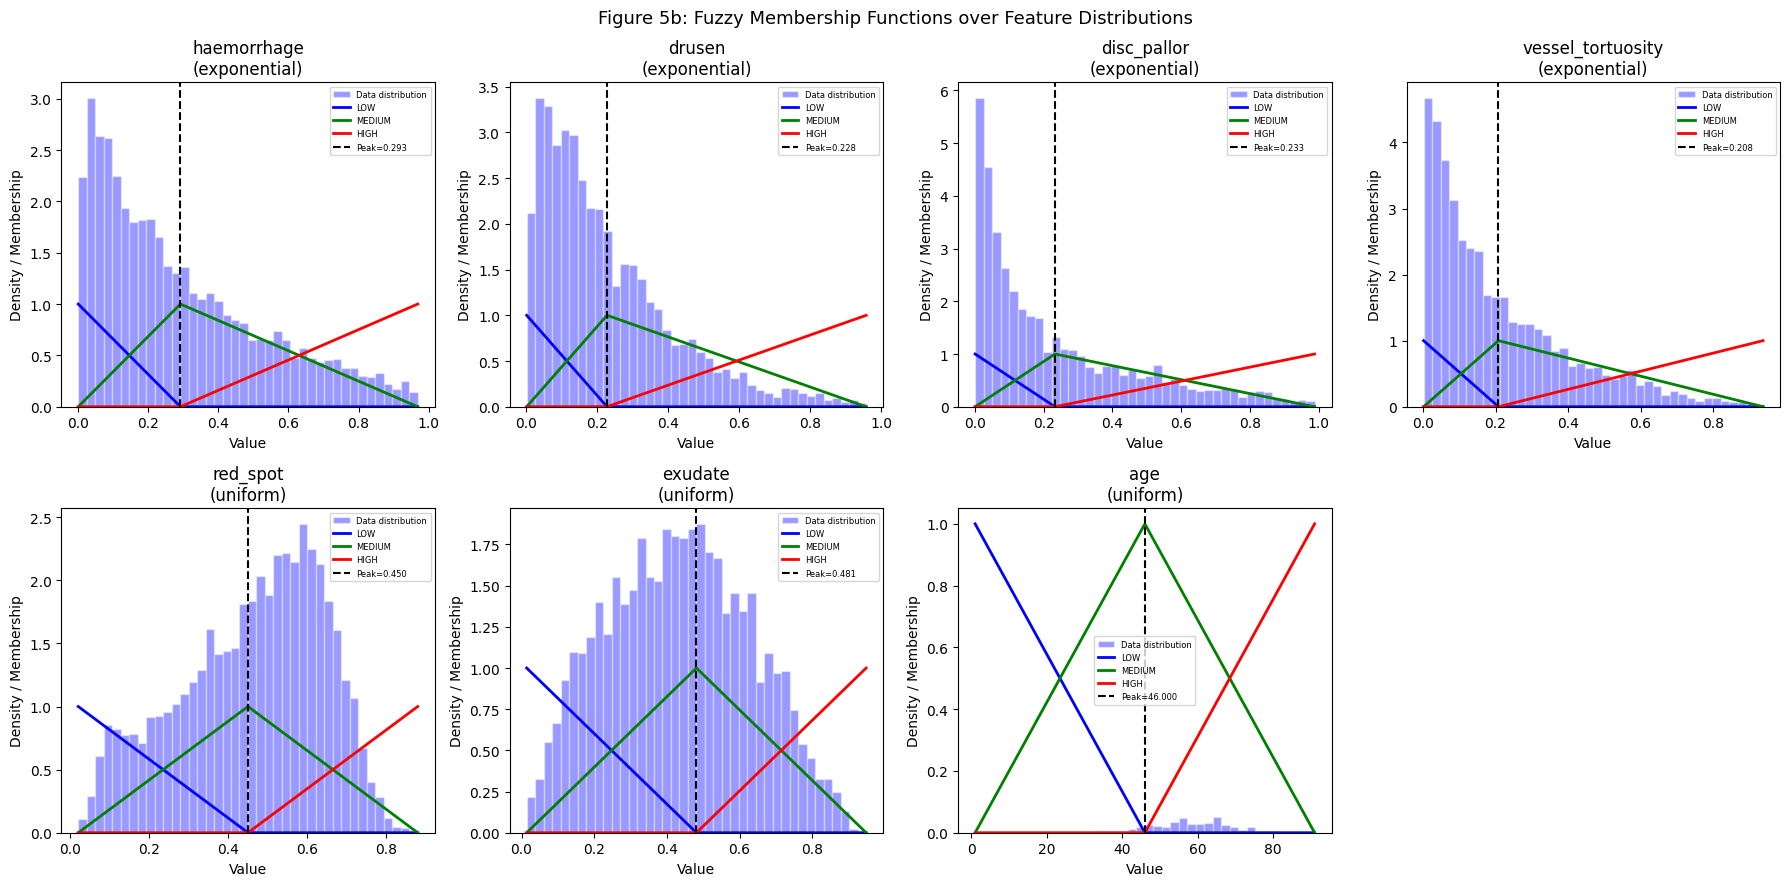

Figure 5b saved.


In [22]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

plot_cols = concepts_list + ['age']

for i, col in enumerate(plot_cols):
    ax = axes[i]
    if col not in dist_params:
        continue

    dist_name, d_min, d_max, peak = dist_params[col]
    data = df_train_feat[col].values

    ax.hist(data, bins=40, density=True, alpha=0.4,color='blue', edgecolor='white', label='Data distribution')

    x_range = np.linspace(d_min, d_max, 300)
    low_vals, med_vals, high_vals = [], [], []
    for val in x_range:
        l, m, h = compute_membership(val, d_min, d_max, peak)
        low_vals.append(l)
        med_vals.append(m)
        high_vals.append(h)

    ax.plot(x_range, low_vals,  color='blue',  linewidth=2, label='LOW')
    ax.plot(x_range, med_vals,  color='green', linewidth=2, label='MEDIUM')
    ax.plot(x_range, high_vals, color='red',   linewidth=2, label='HIGH')
    ax.axvline(x=peak, color='black', linestyle='--', linewidth=1.5,label=f'Peak={peak:.3f}')

    ax.set_title(f"{col}\n({dist_name})")
    ax.set_xlabel('Value')
    ax.set_ylabel('Density / Membership')
    ax.legend(fontsize=6)

axes[-1].axis('off')

plt.suptitle('Figure 5b: Fuzzy Membership Functions over Feature Distributions', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'fig5b_fuzzy_membership.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 5b saved.")

### Cell 23 -- One-Hot Encode Disease Labels
#### Disease labels are converted to one-hot vectors to serve as training targets for the FPT. Each image is represented as a vector of seven values with a one at the position of the correct disease class and zeros elsewhere.

In [23]:
label_to_idx = {'N': 0, 'D': 1, 'G': 2, 'C': 3, 'A': 4, 'H': 5, 'M': 6}
idx_to_name  = {0: 'Normal', 1: 'Diabetic Retinopathy', 2: 'Glaucoma',
                3: 'Cataract', 4: 'AMD', 5: 'Hypertension', 6: 'Myopia'}
disease_names = list(idx_to_name.values())

def to_onehot(labels):
    Y = np.zeros((len(labels), 7))
    for i, l in enumerate(labels):
        if l in label_to_idx:
            Y[i, label_to_idx[l]] = 1
    return Y

Y_train = to_onehot(train_labels)
Y_val   = to_onehot(val_labels)
Y_test  = to_onehot(test_labels)

n_features = X_train_np.shape[1]
n_classes  = Y_train.shape[1]

print(f"Feature matrix:")
print(f"  X_train: {X_train_np.shape}  |  Y_train: {Y_train.shape}")
print(f"  X_val:   {X_val_np.shape}    |  Y_val:   {Y_val.shape}")
print(f"  X_test:  {X_test_np.shape}   |  Y_test:  {Y_test.shape}")

Feature matrix:
  X_train: (3973, 22)  |  Y_train: (3973, 7)
  X_val:   (851, 22)    |  Y_val:   (851, 7)
  X_test:  (860, 22)   |  Y_test:  (860, 7)


---
## Section 5 -- Fuzzy Pattern Tree Classification

### Cell 24 -- GP Parameters

#### Setting up the GP parameters for evolving the Fuzzy Pattern Tree. The WTA7 node defines seven output branches - one per disease class. 30 independent runs of 50 generations each are used, with the best tree selected on the validation set.

In [24]:
def WTA7(a, b, c, d, e, f, g):
    return [a, b, c, d, e, f, g]

def mutUniform(individual, expr, pset):
    index  = random.randrange(len(individual))
    slice_ = individual.searchSubtree(index)
    type_  = individual[index].ret
    individual[slice_] = expr(pset=pset, type_=type_)
    return individual,

N_RUNS          = 30
GENERATIONS     = 50
POPULATION_SIZE = 500
MAX_DEPTH       = 17   
MIN_INIT_DEPTH  = 2
MAX_INIT_DEPTH  = 6
MIN_MUT_DEPTH   = 0
MAX_MUT_DEPTH   = 2
P_CROSSOVER     = 0.8
P_MUTATION      = 0.05
TOURNSIZE       = 7

REPORT_ITEMS = ['gen', 'nevals', 'best_train_fitness', 'best_ind_mce', 'avg_mce',
                'best_ind_depth', 'best_ind_nodes', 'avg_nodes', 'fitness_test',
                'accuracy_test', 'best_phenotype', 'behavioural_diversity',
                'lexicase_avg_steps', 'lexicase_avg_ties_chosen_ind',
                'avg_zeros', 'avg_epsilon', 'variance', 'unique_selected',
                'behavioural_diversity_fitness_cases']

print(f"GP Parameters:")
print(f"  Runs: {N_RUNS} | Generations: {GENERATIONS} | Population: {POPULATION_SIZE}")
print(f"  MAX_DEPTH: {MAX_DEPTH} | Crossover: {P_CROSSOVER} | Mutation: {P_MUTATION}")

GP Parameters:
  Runs: 30 | Generations: 50 | Population: 500
  MAX_DEPTH: 17 | Crossover: 0.8 | Mutation: 0.05


### Cell 25 -- Soft F1 Fitness Function

#### The fitness function used to evaluate each FPT during evolution. Soft Macro F1 loss treats all seven disease classes equally, directly optimising the metric we care about.



In [25]:
def normalise_probs(branch_values):
    clipped  = np.clip(branch_values, 0.0, None)
    row_sums = clipped.sum(axis=1, keepdims=True)
    return np.where(row_sums > 0, clipped / row_sums, 1.0 / branch_values.shape[1])

def soft_f1_loss(branch_values, Y):
    branch_values = normalise_probs(branch_values)
    tp = np.sum(branch_values * Y,       axis=0)
    fp = np.sum(branch_values * (1 - Y), axis=0)
    fn = np.sum((1 - branch_values) * Y, axis=0)
    soft_f1_per_class = 2 * tp / (2 * tp + fp + fn + 1e-8)
    return 1 - np.mean(soft_f1_per_class)

def fitness_eval(individual, points):
    X, Y = points
    n_samples = len(X)
    string_features = ''.join([f"IN{i} = X[:, {i}]; " for i in range(n_features)])
    func = toolbox.compile(expr=individual)
    try:
        local_vars = {}
        exec(string_features, {'X': X}, local_vars)
        inputs  = [local_vars[f'IN{i}'] for i in range(n_features)]
        outputs = func(*inputs)
        if isinstance(outputs, list):
            branch_values = np.clip(np.array(outputs).T, 0, 1)
        else:
            branch_values = np.clip(np.column_stack([outputs] * n_classes), 0, 1)
        loss  = soft_f1_loss(branch_values, Y)
        preds = np.argmax(branch_values, axis=1)
        true  = np.argmax(Y, axis=1)
        individual.mce  = 1 - np.mean(preds == true)
        individual.nodes = len(individual)
        individual.behaviour = preds
        return (loss,)
    except Exception:
        individual.mce  = 1.0
        individual.nodes  = len(individual)
        individual.behaviour = np.zeros(n_samples, dtype=int)
        return (1.0,)

print("Fitness: Normalised Soft Macro F1 Loss")

Fitness: Normalised Soft Macro F1 Loss


### Cell 26 -- GP Toolbox

#### The GP toolbox registers all fuzzy operators, selection strategy and genetic operators used during FPT evolution. Tournament selection is used with a field of 7 candidates, and tree depth is capped at 17 to control complexity.

In [26]:
def create_toolbox():
    if hasattr(creator, 'FitnessMin'): del creator.FitnessMin
    if hasattr(creator, 'Individual'): del creator.Individual

    pset = gp.PrimitiveSetTyped("MAIN", itertools.repeat(float, n_features), list, "IN")
    pset.addPrimitive(WTA7,         [float] * 7, list)
    pset.addPrimitive(WA,           [float, float, str], float)
    pset.addPrimitive(OWA,          [float, float, str], float)
    pset.addPrimitive(minimum,      [float, float], float)
    pset.addPrimitive(maximum,      [float, float], float)
    pset.addPrimitive(dilator,      [float], float)
    pset.addPrimitive(concentrator, [float], float)
    pset.addPrimitive(complement,   [float], float)

    def extend(x): return x
    pset.addPrimitive(extend, [str], str)
    for w in ['0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9']:
        pset.addTerminal(w, str)
    pset.addTerminal([], list)

    creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
    creator.create("Individual", gp.PrimitiveTree, fitness=creator.FitnessMin)

    tb = base.Toolbox()
    tb.register("expr",       gp.genHalfAndHalf, pset=pset, min_=MIN_INIT_DEPTH, max_=MAX_INIT_DEPTH)
    tb.register("individual", tools.initIterate,  creator.Individual, tb.expr)
    tb.register("population", tools.initRepeat,   list, tb.individual)
    tb.register("compile",    gp.compile,          pset=pset)
    tb.register("evaluate",   fitness_eval)
    tb.register("select",     tools.selTournament, tournsize=TOURNSIZE)
    tb.register("mate",       gp.cxOnePoint)
    tb.register("expr_mut",   gp.genGrow,          min_=MIN_MUT_DEPTH, max_=MAX_MUT_DEPTH)
    tb.register("mutate",     mutUniform,           expr=tb.expr_mut, pset=pset)
    tb.decorate("mate",   gp.staticLimit(key=operator.attrgetter("height"), max_value=MAX_DEPTH))
    tb.decorate("mutate", gp.staticLimit(key=operator.attrgetter("height"), max_value=MAX_DEPTH))
    return tb, pset

toolbox, pset = create_toolbox()
print("GP toolbox ready.")

GP toolbox ready.


### Cell 27 -- Run 30 GP Runs

#### 30 independent GP runs are executed, each evolving a population of 500 trees over 50 generations. The best tree from each run is evaluated on the validation set and the overall best tree across all runs is retained for final testing.

In [27]:
feature_names = []
for c in concepts_list:
    for level in ['LOW', 'MEDIUM', 'HIGH']:
        feature_names.append(f'{c}_{level}')
for level in ['LOW', 'MEDIUM', 'HIGH']:
    feature_names.append(f'age_{level}')
feature_names.append('sex')

best_overall_tree    = None
best_overall_val_f1  = -1
best_overall_run     = -1
run_results          = []
feature_counts       = np.zeros(n_features, dtype=int)
val_f1_per_run       = []

print(f"Starting {N_RUNS} GP runs x {GENERATIONS} generations each...")
print()

for run in range(1, N_RUNS + 1):
    print(f"--- Run {run}/{N_RUNS} ---")
    np.random.seed(run)
    random.seed(run)
    toolbox, pset = create_toolbox()
    toolbox.register("evaluate", fitness_eval)
    pop = toolbox.population(n=POPULATION_SIZE)
    hof = tools.HallOfFame(1)
    population, logbook = eaSimple(
        population=pop, toolbox=toolbox,
        cxpb=P_CROSSOVER, mutpb=P_MUTATION, ngen=GENERATIONS,
        points_train=[X_train_np, Y_train],
        points_test=[X_val_np, Y_val],
        report_items=REPORT_ITEMS, halloffame=hof
    )
    best_tree    = hof.items[0]
    fitness_eval(best_tree, [X_val_np, Y_val])
    val_acc      = 1 - best_tree.mce
    val_macro_f1 = f1_score(
        np.argmax(Y_val, axis=1), best_tree.behaviour,
        average='macro', zero_division=0
    )
    run_results.append({'run': run, 'val_accuracy': val_acc, 'val_macro_f1': val_macro_f1, 'nodes': len(best_tree)})
    print(f"Run {run} | Val Accuracy: {val_acc:.4f} | Val Macro F1: {val_macro_f1:.4f} | Nodes: {len(best_tree)}")

    # Collect feature usage from this run's best tree — no re-running needed
    tree_str = str(best_tree)
    for i in range(n_features):
        if f'IN{i}' in tree_str:
            feature_counts[i] += 1

    # Track val F1 per run for statistical analysis
    val_f1_per_run.append(val_macro_f1)

    if val_macro_f1 > best_overall_val_f1:
        best_overall_val_f1 = val_macro_f1
        best_overall_tree   = best_tree
        best_overall_run    = run
        print(f"  *** New best: Run {run} | Val Accuracy: {val_acc:.4f} | Val Macro F1: {val_macro_f1:.4f} ***")

print()
print(f"All {N_RUNS} runs complete.")
print(f"Best tree: Run {best_overall_run} | Val Macro F1: {best_overall_val_f1:.4f}")

np.save(os.path.join(OUTPUT_PATH, 'val_f1_per_run_softf1.npy'), np.array(val_f1_per_run))
print("Val F1 per run saved.")

Starting 30 GP runs x 50 generations each...

--- Run 1/30 ---
gen = 0 , fitness = 0.8291121538258972 , MCE = 0.8379058645859552 , evals = 500
gen = 1 , fitness = 0.8193182784113058 , MCE = 0.6833626982129373 , evals = 418
gen = 2 , fitness = 0.8147005628596841 , MCE = 0.624213440724893 , evals = 410
gen = 3 , fitness = 0.8087347099400599 , MCE = 0.5461867606342814 , evals = 385
gen = 4 , fitness = 0.7970186159548318 , MCE = 0.5439214699219733 , evals = 394
gen = 5 , fitness = 0.7827326217035511 , MCE = 0.5426629750818022 , evals = 404
gen = 6 , fitness = 0.764637212365884 , MCE = 0.5285678328718852 , evals = 429
gen = 7 , fitness = 0.7644022573528416 , MCE = 0.48955449282657937 , evals = 383
gen = 8 , fitness = 0.753422277637441 , MCE = 0.5179964762144476 , evals = 415
gen = 9 , fitness = 0.7382349512556137 , MCE = 0.5023911401963252 , evals = 430
gen = 10 , fitness = 0.7347252504158855 , MCE = 0.505411527812736 , evals = 407
gen = 11 , fitness = 0.7341734138915457 , MCE = 0.507425119

---
## Section 6 -- Evaluation 

### Cell 28 -- Final Test Set Evaluation

#### The best tree from validation is applied to the test set to produce the final classification results, including accuracy, macro F1 and a per-class breakdown.

In [28]:
# Evaluating best tree on test set 
fitness_eval(best_overall_tree, [X_test_np, Y_test])

string_features = ''.join([f"IN{i} = X_test_np[:, {i}]; " for i in range(n_features)])
func = toolbox.compile(expr=best_overall_tree)
local_vars = {}
exec(string_features, {'X_test_np': X_test_np}, local_vars)
inputs  = [local_vars[f'IN{i}'] for i in range(n_features)]
outputs = func(*inputs)
branch_values = np.clip(np.array(outputs).T, 0, 1)

final_predictions = np.argmax(branch_values, axis=1)
true_classes = np.argmax(Y_test, axis=1)

test_accuracy = accuracy_score(true_classes, final_predictions)
macro_f1 = f1_score(true_classes, final_predictions, average='macro', zero_division=0)

print("=" * 60)
print("RETINEXPLAIN — Final Results on Test Set")
print("=" * 60)
print()
print(f"Accuracy : {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")
print(f"Macro F1 : {macro_f1:.4f}")
print()
print(classification_report(true_classes, final_predictions, target_names=disease_names, zero_division=0))

RETINEXPLAIN — Final Results on Test Set

Accuracy : 0.5663 (56.63%)
Macro F1 : 0.4334

                      precision    recall  f1-score   support

              Normal       0.61      0.73      0.67       435
Diabetic Retinopathy       0.57      0.38      0.46       250
            Glaucoma       0.33      0.48      0.39        42
            Cataract       0.71      0.66      0.68        44
                 AMD       0.32      0.19      0.24        36
        Hypertension       0.08      0.11      0.09        18
              Myopia       0.60      0.43      0.50        35

            accuracy                           0.57       860
           macro avg       0.46      0.43      0.43       860
        weighted avg       0.57      0.57      0.56       860



### Cell 29 -- Confusion Matrix

#### Confusion matrices showing prediction counts (left) and row-normalised percentages (right). The diagonal values represent correctly classified samples for each disease class.

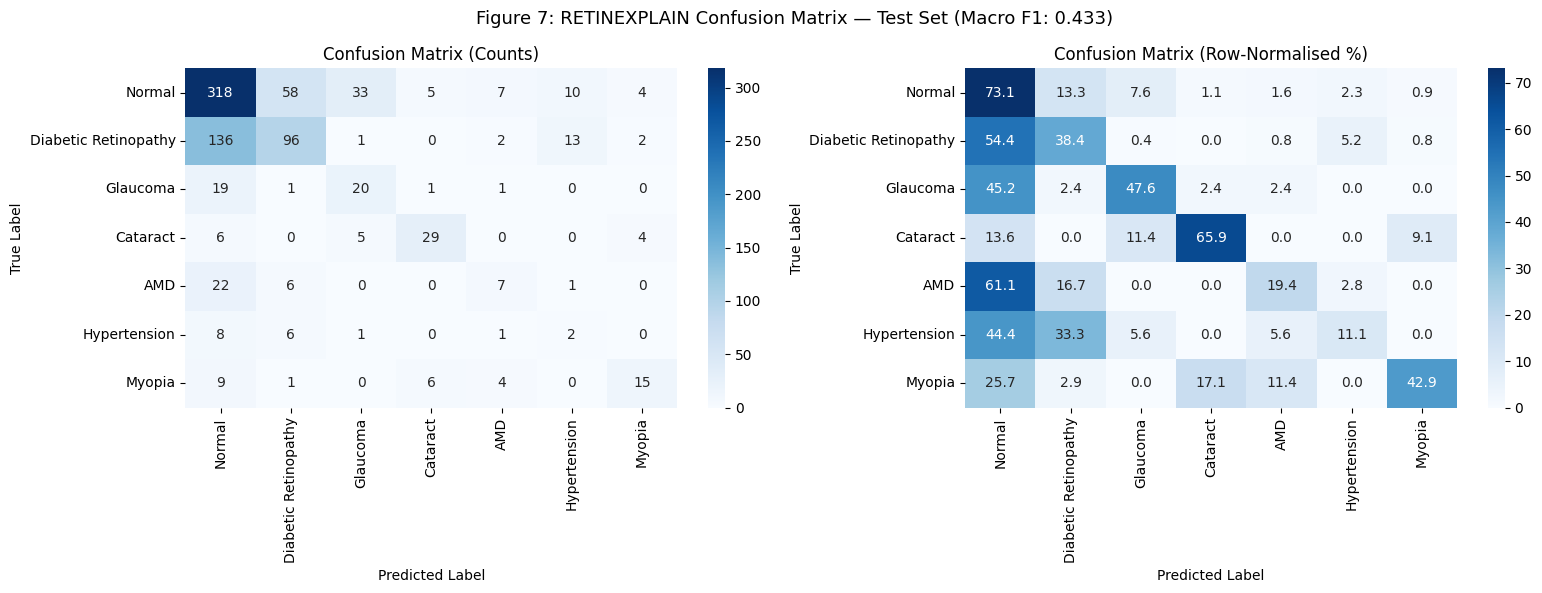

Figure 7 saved.


In [29]:
cm = confusion_matrix(true_classes, final_predictions)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=disease_names, yticklabels=disease_names, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',xticklabels=disease_names, yticklabels=disease_names, ax=axes[1])
axes[1].set_title('Confusion Matrix (Row-Normalised %)')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.suptitle(f'Figure 7: RETINEXPLAIN Confusion Matrix — Test Set (Macro F1: {macro_f1:.3f})', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'fig7_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 7 saved.")

### Cell 30 -- Per-Class Performance

#### Precision, recall and F1 score for each disease class on the test set. The dashed line shows the macro-averaged F1 across all seven classes.

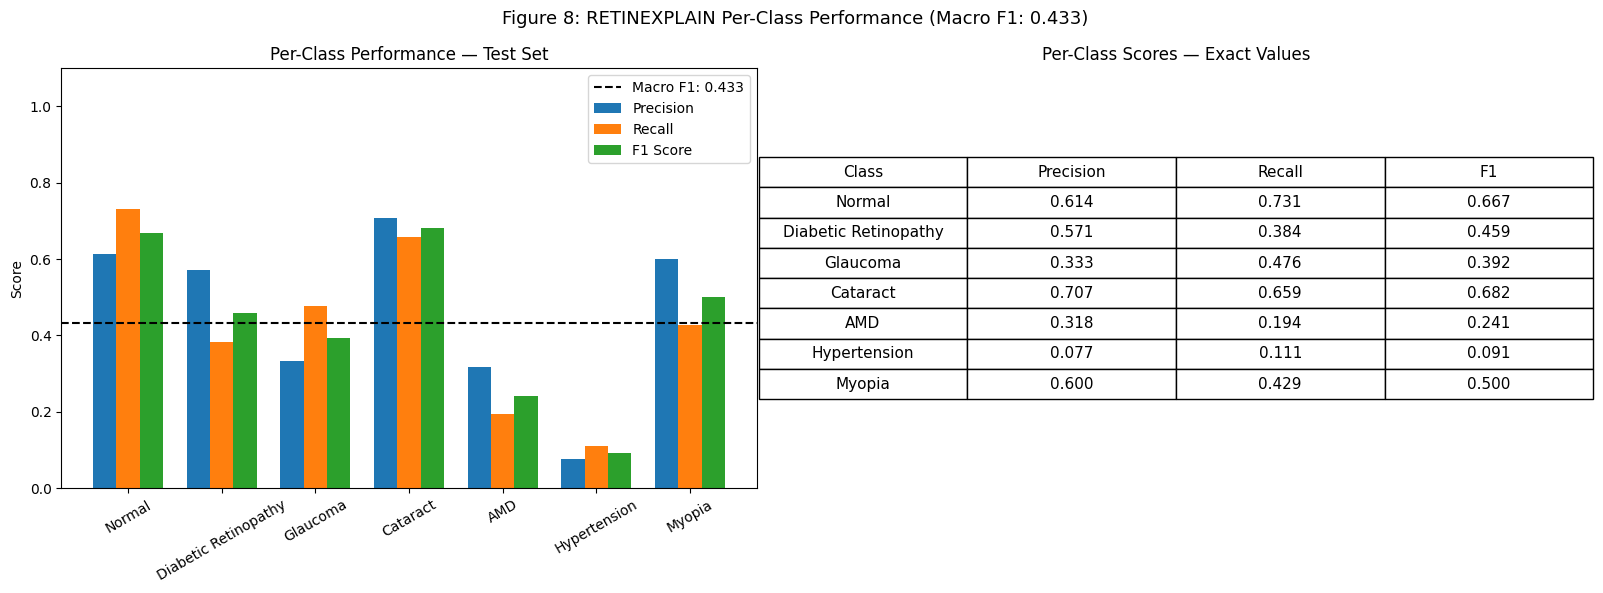

Figure 8 saved.


In [30]:
precisions = precision_score(true_classes, final_predictions, average=None, zero_division=0, labels=list(range(7)))
recalls = recall_score( true_classes, final_predictions, average=None, zero_division=0, labels=list(range(7)))
f1s   = f1_score(true_classes, final_predictions, average=None, zero_division=0, labels=list(range(7)))

x = np.arange(len(disease_names))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(x - width, precisions, width, label='Precision')
axes[0].bar(x, recalls,  width, label='Recall')
axes[0].bar(x + width, f1s, width, label='F1 Score')
axes[0].axhline(y=macro_f1, color='black', linestyle='--', label=f'Macro F1: {macro_f1:.3f}')
axes[0].set_title('Per-Class Performance — Test Set')
axes[0].set_xticks(x)
axes[0].set_xticklabels(disease_names, rotation=30)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.1)
axes[0].legend()

table_data = []
for i, name in enumerate(disease_names):
    table_data.append([name, f'{precisions[i]:.3f}', f'{recalls[i]:.3f}', f'{f1s[i]:.3f}'])

table = axes[1].table(
    cellText=table_data,
    colLabels=['Class', 'Precision', 'Recall', 'F1'],
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.0)
axes[1].axis('off')
axes[1].set_title('Per-Class Scores — Exact Values')

plt.suptitle(f'Figure 8: RETINEXPLAIN Per-Class Performance (Macro F1: {macro_f1:.3f})', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'fig8_per_class_performance.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 8 saved.")

### Cell 31 -- GP Runs Summary

#### Validation macro F1 across all 30 GP runs. The green bar indicates the best run selected for final testing. The red dashed line shows the mean macro F1 across runs.

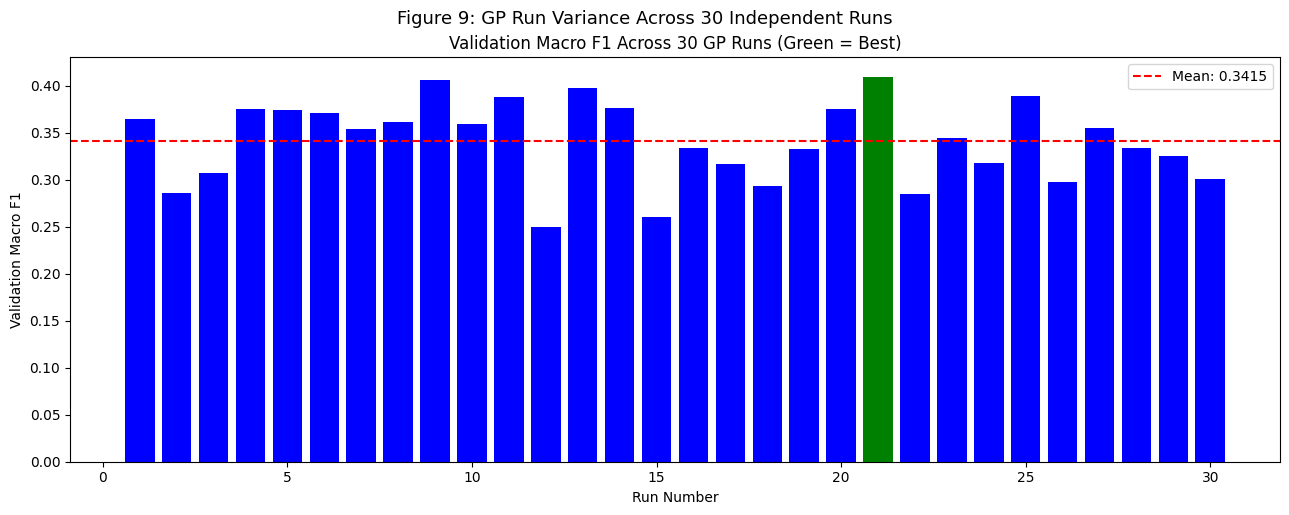

Best run : Run 21 | Macro F1 0.4099
Mean     : 0.3415
Std      : 0.0421


In [31]:
df_results = pd.DataFrame(run_results)
plt.figure(figsize=(13, 5))
bar_colors = ['green' if r == best_overall_run else 'blue' for r in df_results['run']]
plt.bar(df_results['run'], df_results['val_macro_f1'], color=bar_colors)
plt.axhline(y=df_results['val_macro_f1'].mean(), color='red', linestyle='--', label=f"Mean: {df_results['val_macro_f1'].mean():.4f}")
plt.xlabel('Run Number')
plt.ylabel('Validation Macro F1')
plt.title(f'Validation Macro F1 Across {N_RUNS} GP Runs (Green = Best)')
plt.legend()
plt.tight_layout()
plt.suptitle('Figure 9: GP Run Variance Across 30 Independent Runs', fontsize=13, y=1.02)
plt.savefig(os.path.join(OUTPUT_PATH, 'fig9_gp_runs.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Best run : Run {best_overall_run} | Macro F1 {df_results.loc[df_results['run'] == best_overall_run, 'val_macro_f1'].values[0]:.4f}")
print(f"Mean     : {df_results['val_macro_f1'].mean():.4f}")
print(f"Std      : {df_results['val_macro_f1'].std(ddof=0):.4f}")

### Cell 32 -- FPT Tree Size Analysis

#### Number of nodes in the best individual across all 30 GP runs. Smaller trees are more interpretable - a clinician can more easily follow a compact expression than a large one. The green bar marks the best overall run selected by validation Macro F1.

FPT Tree Size Analysis (30 runs)
----------------------------------------
  Mean nodes    : 35.7
  Std nodes     : 13.1
  Min nodes     : 15
  Max nodes     : 79
  Best run nodes: 45



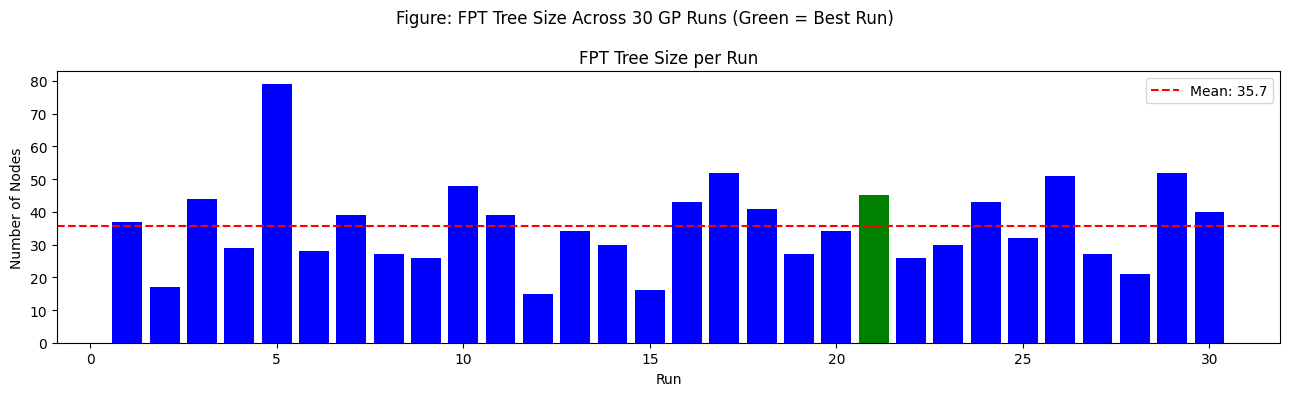

Figure saved: fig_tree_size.png


In [32]:
tree_sizes = [r['nodes'] for r in run_results]

print("FPT Tree Size Analysis (30 runs)")
print("-" * 40)
print(f"  Mean nodes    : {np.mean(tree_sizes):.1f}")
print(f"  Std nodes     : {np.std(tree_sizes):.1f}")
print(f"  Min nodes     : {np.min(tree_sizes)}")
print(f"  Max nodes     : {np.max(tree_sizes)}")
print(f"  Best run nodes: {len(best_overall_tree)}")
print()

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(range(1, len(tree_sizes)+1), tree_sizes, color=['green' if i+1 == best_overall_run else 'blue' for i in range(len(tree_sizes))])
ax.axhline(y=np.mean(tree_sizes), color='red', linestyle='--', label=f'Mean: {np.mean(tree_sizes):.1f}')
ax.set_xlabel('Run')
ax.set_ylabel('Number of Nodes')
ax.set_title('FPT Tree Size per Run')
ax.legend()
plt.suptitle('Figure: FPT Tree Size Across 30 GP Runs (Green = Best Run)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'fig_tree_size.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: fig_tree_size.png")

### Cell 33 -- Feature Usage Frequency Across 30 Runs

#### Counts how many times each of the 22 fuzzy features appears in the best tree across 30 independent GP runs. Features appearing consistently above the 50% threshold (15/30) are robustly useful. Blue bars are concept features, orange bars are age and sex.

Feature usage frequency (out of 30 runs):

  haemorrhage_LOW               :  5/30
  haemorrhage_MEDIUM            : 30/30
  haemorrhage_HIGH              : 13/30
  drusen_LOW                    :  7/30
  drusen_MEDIUM                 : 12/30
  drusen_HIGH                   : 30/30
  disc_pallor_LOW               :  5/30
  disc_pallor_MEDIUM            :  2/30
  disc_pallor_HIGH              : 30/30
  vessel_tortuosity_LOW         :  3/30
  vessel_tortuosity_MEDIUM      :  1/30
  vessel_tortuosity_HIGH        : 25/30
  red_spot_LOW                  : 30/30
  red_spot_MEDIUM               : 10/30
  red_spot_HIGH                 :  1/30
  exudate_LOW                   :  3/30
  exudate_MEDIUM                :  9/30
  exudate_HIGH                  : 30/30
  age_LOW                       : 12/30
  age_MEDIUM                    :  1/30
  age_HIGH                      :  1/30
  sex                           :  3/30


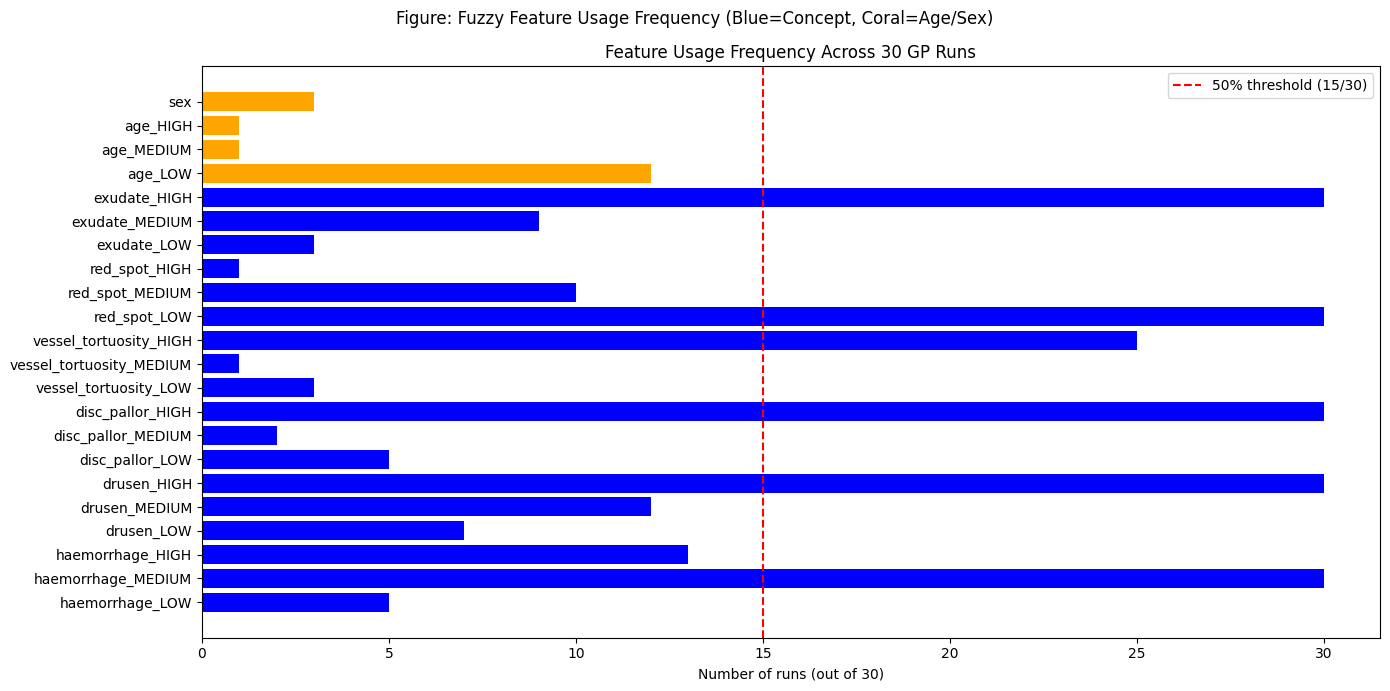

Figure saved: fig_feature_usage.png


In [33]:
print("Feature usage frequency (out of 30 runs):")
print()
for i, (name, count) in enumerate(zip(feature_names, feature_counts)):
    print(f"  {name:<30}: {count:2d}/30")

fig, ax = plt.subplots(figsize=(14, 7))
colors = ['blue' if any(c in name for c in concepts_list)
          else 'orange' for name in feature_names]
ax.barh(feature_names, feature_counts, color=colors)
ax.axvline(x=15, color='red', linestyle='--', label='50% threshold (15/30)')
ax.set_xlabel('Number of runs (out of 30)')
ax.set_title('Feature Usage Frequency Across 30 GP Runs')
ax.legend()
plt.suptitle('Figure: Fuzzy Feature Usage Frequency (Blue=Concept, Coral=Age/Sex)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'fig_feature_usage.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: fig_feature_usage.png")

### Cell 34 -- Best FPT Branch Expressions

#### The best overall FPT selected by validation Macro F1 is presented as a human-readable expression. Feature indices IN0 to IN21 are substituted with their fuzzy feature names. Each of the 7 branches of the WTA node corresponds to one disease class - the branch producing the highest score for a given patient determines the predicted diagnosis.

In [34]:
feature_names_map = {f'IN{i}': name for i, name in enumerate(feature_names)}

def pretty_print_expr(expr_str, feature_map):
    result = expr_str
    for key in sorted(feature_map.keys(), key=len, reverse=True):
        result = result.replace(key, feature_map[key])
    return result

best_tree_str = str(best_overall_tree)
readable = pretty_print_expr(best_tree_str, feature_names_map)

print("=" * 70)
print("BEST FPT OVERALL — Readable Expression")
print(f"Best Run: {best_overall_run} | Val Macro F1: {best_overall_val_f1:.4f} | Nodes: {len(best_overall_tree)}")
print("=" * 70)
print()
print("Raw expression:")
print(best_tree_str[:800])
print("..." if len(best_tree_str) > 800 else "")
print()
print("Readable expression (feature names substituted):")
print(readable[:1500])
print("..." if len(readable) > 1500 else "")
print()
print("Disease class branch mapping:")
for i, name in enumerate(disease_names):
    print(f"  Branch {i}: {name}")

BEST FPT OVERALL — Readable Expression
Best Run: 21 | Val Macro F1: 0.4099 | Nodes: 45

Raw expression:
WTA7(complement(complement(concentrator(concentrator(IN13)))), IN17, concentrator(complement(complement(IN8))), maximum(concentrator(concentrator(maximum(concentrator(IN12), OWA(IN5, IN18, '0.1')))), minimum(IN18, concentrator(maximum(concentrator(IN12), OWA(IN5, IN18, '0.1'))))), concentrator(IN5), concentrator(minimum(dilator(minimum(IN11, IN4)), IN11)), concentrator(minimum(IN12, concentrator(IN6))))


Readable expression (feature names substituted):
WTA7(complement(complement(concentrator(concentrator(red_spot_MEDIUM)))), exudate_HIGH, concentrator(complement(complement(disc_pallor_HIGH))), maximum(concentrator(concentrator(maximum(concentrator(red_spot_LOW), OWA(drusen_HIGH, age_LOW, '0.1')))), minimum(age_LOW, concentrator(maximum(concentrator(red_spot_LOW), OWA(drusen_HIGH, age_LOW, '0.1'))))), concentrator(drusen_HIGH), concentrator(minimum(dilator(minimum(vessel_tortuosity_H

### Cell 35 -- Statistical Validity: 30-Run Val Macro F1 Distribution

#### Distribution of validation Macro F1 scores across 30 independent GP runs for the Soft F1 fitness function. Shows the mean, spread and consistency of the fitness function across independent runs. 

30-Run Validation Macro F1 Distribution
  Mean : 0.3415
  Std  : 0.0421
  Min  : 0.2503
  Max  : 0.4099


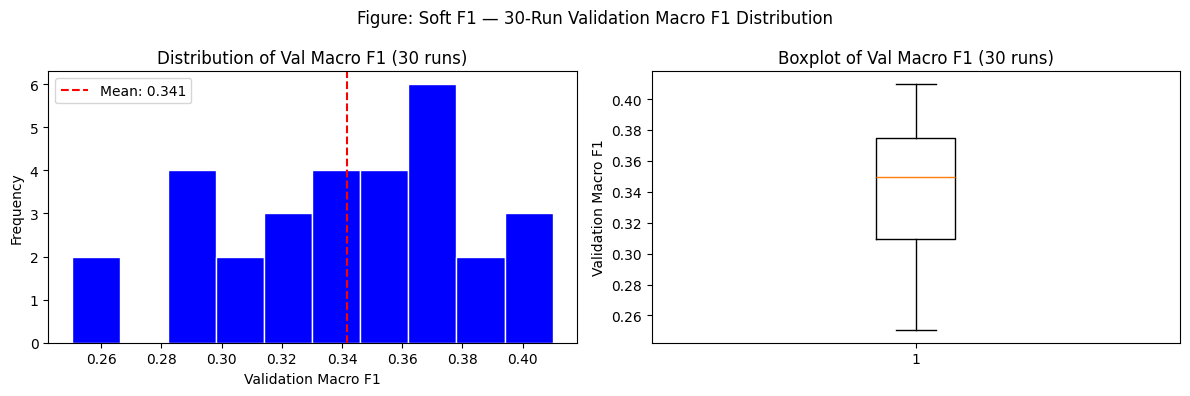

Figure saved: fig_stat_distribution.png


In [35]:
print("30-Run Validation Macro F1 Distribution")
print("=" * 60)
print(f"  Mean : {np.mean(val_f1_per_run):.4f}")
print(f"  Std  : {np.std(val_f1_per_run):.4f}")
print(f"  Min  : {np.min(val_f1_per_run):.4f}")
print(f"  Max  : {np.max(val_f1_per_run):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(val_f1_per_run, bins=10, color='blue', edgecolor='white')
axes[0].axvline(np.mean(val_f1_per_run), color='red', linestyle='--',
                label=f'Mean: {np.mean(val_f1_per_run):.3f}')
axes[0].set_xlabel('Validation Macro F1')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Val Macro F1 (30 runs)')
axes[0].legend()
axes[1].boxplot(val_f1_per_run)
axes[1].set_ylabel('Validation Macro F1')
axes[1].set_title('Boxplot of Val Macro F1 (30 runs)')
plt.suptitle('Figure: Soft F1 — 30-Run Validation Macro F1 Distribution', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'fig_stat_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: fig_stat_distribution.png")

### Cell 36 -- Patient-Level Clinical Explanations

#### One correctly classified example is shown for each disease class, displaying the six concept scores detected in the retinal image. Each score is labelled LOW, MEDIUM or HIGH to indicate the strength of that clinical sign.

In [36]:
print("RETINEXPLAIN — Example Patient Predictions with Clinical Explanations")
print()

shown = set()
count = 0

for i in range(len(final_predictions)):
    pred = final_predictions[i]
    true = true_classes[i]

    if pred == true and pred not in shown and count < 7:
        shown.add(pred)
        count += 1

        raw_scores = test_scores[i] if i < len(test_scores) else np.zeros(6)

        print(f"Patient {count} — Predicted: {idx_to_name[pred]} [CORRECT]")
        print(f"True diagnosis: {idx_to_name[true]}")
        print()
        print(f"  Clinical signs detected in retinal image:")
        print(f"  {'Sign':<22}  {'Score':>6}  {'Level':<8}  {'Confidence':>10}")
        print(f"  {'-' * 55}")

        for j, display_name in enumerate(concepts_display):
            score = raw_scores[j]
            if score >= 0.67:
                level = 'HIGH'
            elif score >= 0.33:
                level = 'MEDIUM'
            else:
                level = 'LOW'
            print(f"  {display_name:<22}  {score:>6.3f}  {level:<8}  {score*100:>9.0f}%")

        print()
        print(f"  Based on the detected clinical signs, the model predicted {idx_to_name[pred]}.")
        print("-" * 60)
        print()

RETINEXPLAIN — Example Patient Predictions with Clinical Explanations

Patient 1 — Predicted: Normal [CORRECT]
True diagnosis: Normal

  Clinical signs detected in retinal image:
  Sign                     Score  Level     Confidence
  -------------------------------------------------------
  Haemorrhage              0.340  MEDIUM           34%
  Drusen                   0.191  LOW              19%
  Disc Pallor              0.031  LOW               3%
  Vessel Tortuosity        0.327  LOW              33%
  Red Spot                 0.635  MEDIUM           63%
  Exudate                  0.502  MEDIUM           50%

  Based on the detected clinical signs, the model predicted Normal.
------------------------------------------------------------

Patient 2 — Predicted: Myopia [CORRECT]
True diagnosis: Myopia

  Clinical signs detected in retinal image:
  Sign                     Score  Level     Confidence
  -------------------------------------------------------
  Haemorrhage             

### Cell 37 -- Final Summary

#### Summary of the full RETINEXPLAIN pipeline configuration and final test set results.

In [37]:
print("=" * 60)
print("RETINEXPLAIN — Pipeline Summary")
print("=" * 60)
print()
print(f"Dataset         : ODIR-5K — {len(df_clean)} images, 7 disease classes")
print(f"Fuzzy features  : {n_features} (6 concepts x 3 sets + age x 3 sets + sex)")
print(f"Fuzzification   : Adaptive triangular")
print(f"Fitness         : Soft Macro F1 Loss")
print(f"GP evolution    : {N_RUNS} runs x {GENERATIONS} generations | MAX_DEPTH={MAX_DEPTH}")
print(f"Best GP run     : Run {best_overall_run}")
print()
print("Test Set Results:")
print(f"  Accuracy : {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")
print(f"  Macro F1 : {macro_f1:.4f}")
print()
print("Per-class F1:")
f1_per_class = f1_score(true_classes, final_predictions, average=None, zero_division=0, labels=list(range(7)))
for i, name in enumerate(disease_names):
    print(f"  {name:<25}  {f1_per_class[i]:.3f}")

RETINEXPLAIN — Pipeline Summary

Dataset         : ODIR-5K — 5684 images, 7 disease classes
Fuzzy features  : 22 (6 concepts x 3 sets + age x 3 sets + sex)
Fuzzification   : Adaptive triangular
Fitness         : Soft Macro F1 Loss
GP evolution    : 30 runs x 50 generations | MAX_DEPTH=17
Best GP run     : Run 21

Test Set Results:
  Accuracy : 0.5663 (56.63%)
  Macro F1 : 0.4334

Per-class F1:
  Normal                     0.667
  Diabetic Retinopathy       0.459
  Glaucoma                   0.392
  Cataract                   0.682
  AMD                        0.241
  Hypertension               0.091
  Myopia                     0.500
